# AutoLyrics: Whisper LoRA for Singing Transcription (JamendoLyrics)

In [9]:
# install
!pip install -q transformers peft accelerate gradio jiwer evaluate imageio-ffmpeg huggingface_hub
!pip uninstall -q -y torchao

In [10]:
# config
import os, gc, csv, json, time, subprocess, warnings
from pathlib import Path
from dataclasses import dataclass
from typing import Any
warnings.filterwarnings("ignore")
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")

import numpy as np
import torch
import imageio_ffmpeg
from huggingface_hub import hf_hub_download
from torch.utils.data import Dataset
from transformers import (WhisperProcessor, WhisperForConditionalGeneration,
                          Seq2SeqTrainer, Seq2SeqTrainingArguments, EarlyStoppingCallback)
from peft import LoraConfig, get_peft_model
import evaluate

REPO = "jamendolyrics/jamendolyrics"
MODEL_NAME = "openai/whisper-small"
LANG = "English"
LR, EPOCHS, PATIENCE = 3e-4, 8, 3
SR, SEED = 16000, 42
MIN_SEG, TARGET_SEG, MAX_SEG = 4.0, 10.0, 14.0
torch.manual_seed(SEED); np.random.seed(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
USE_BF16 = DEVICE == "cuda" and torch.cuda.is_bf16_supported()
FFMPEG = imageio_ffmpeg.get_ffmpeg_exe()
CKPT = Path("jamendo_ckpt"); CKPT.mkdir(exist_ok=True)
WAVDIR = Path("jamendo_wav16"); WAVDIR.mkdir(exist_ok=True)
print(DEVICE, "bf16:", USE_BF16, MODEL_NAME)

cuda bf16: True openai/whisper-small


In [11]:
# audio and lyric helpers
def decode_mp3(path):
    out = subprocess.run([FFMPEG, "-v", "error", "-i", str(path), "-ar", str(SR),
                          "-ac", "1", "-f", "f32le", "pipe:1"], capture_output=True)
    return np.clip(np.frombuffer(out.stdout, dtype=np.float32).copy(), -1.0, 1.0)

def song_wav(stem):
    cache = WAVDIR / f"{stem}.npy"
    if cache.exists():
        return np.load(cache)
    mp3 = hf_hub_download(REPO, f"subsets/en/mp3/{stem}.mp3", repo_type="dataset")
    a = decode_mp3(mp3); np.save(cache, a); return a

def read_words(stem):
    wt = hf_hub_download(REPO, f"lyrics/{stem}.words.txt", repo_type="dataset")
    words = [w.strip() for w in Path(wt).read_text(encoding="utf-8").splitlines() if w.strip()]
    wc = hf_hub_download(REPO, f"annotations/words/{stem}.csv", repo_type="dataset")
    rows = list(csv.DictReader(open(wc, encoding="utf-8")))
    n = min(len(words), len(rows)); out = []
    for i in range(n):
        le = rows[i].get("line_end", "nan")
        is_le = not (le is None or le == "" or le.lower() == "nan")
        out.append((words[i], float(rows[i]["word_start"]), float(rows[i]["word_end"]), is_le))
    return out

def segment_song(stem):
    audio = song_wav(stem); words = read_words(stem)
    segs, cur, seg_start = [], [], None
    def flush():
        if not cur: return
        t0, t1 = seg_start, cur[-1][2]
        text = " ".join(w[0] for w in cur).strip()
        if text and (t1 - t0) >= MIN_SEG:
            clip = audio[int(t0*SR):int(t1*SR)]
            if len(clip) >= int(MIN_SEG*SR):
                segs.append({"song": stem, "text": text, "audio": clip})
    for w in words:
        if not cur: seg_start = w[1]
        cur.append(w); dur = w[2] - seg_start
        if (dur >= TARGET_SEG and w[3]) or dur >= MAX_SEG:
            flush(); cur = []
    flush(); return segs

In [12]:
# build segments and song-disjoint split
master = hf_hub_download(REPO, "JamendoLyrics.csv", repo_type="dataset")
stems = [r["Filepath"].replace(".mp3", "") for r in csv.DictReader(open(master, encoding="utf-8"))
         if r["Language"] == LANG]

rng = np.random.RandomState(SEED); idx = rng.permutation(len(stems))
n_test = n_val = max(2, len(stems)//6)
test_songs = {stems[i] for i in idx[:n_test]}
val_songs  = {stems[i] for i in idx[n_test:n_test+n_val]}

tr_segs, val_segs, te_segs = [], [], []
for stem in stems:
    segs = segment_song(stem)
    (te_segs if stem in test_songs else val_segs if stem in val_songs else tr_segs).extend(segs)
print(f"songs {len(stems)} | segments train={len(tr_segs)} val={len(val_segs)} test={len(te_segs)}")

songs 20 | segments train=169 val=36 test=49


In [13]:
# dataset and collator
processor = WhisperProcessor.from_pretrained(MODEL_NAME, language="english", task="transcribe")

class SegDataset(Dataset):
    def __init__(self, segs): self.segs = segs
    def __len__(self): return len(self.segs)
    def __getitem__(self, i):
        s = self.segs[i]
        feats = processor.feature_extractor(s["audio"], sampling_rate=SR, return_tensors="np").input_features[0]
        labels = processor.tokenizer(s["text"], return_tensors="np", padding=False,
                                     truncation=True, max_length=448).input_ids[0]
        return {"input_features": feats, "labels": labels}

@dataclass
class Collator:
    processor: Any
    def __call__(self, features):
        batch = self.processor.feature_extractor.pad(
            [{"input_features": f["input_features"]} for f in features], return_tensors="pt")
        lb = self.processor.tokenizer.pad([{"input_ids": f["labels"]} for f in features], return_tensors="pt")
        labels = lb["input_ids"].masked_fill(lb.attention_mask.ne(1), -100)
        if (labels[:, 0] == self.processor.tokenizer.bos_token_id).all().cpu().item():
            labels = labels[:, 1:]
        batch["labels"] = labels; return batch

tr_ds, val_ds, te_ds = SegDataset(tr_segs), SegDataset(val_segs), SegDataset(te_segs)
collator = Collator(processor)

In [14]:
# metrics, model, eval
from transformers.models.whisper.english_normalizer import BasicTextNormalizer
norm = BasicTextNormalizer()
wer_metric, cer_metric = evaluate.load("wer"), evaluate.load("cer")
def nlist(xs): return [(norm(x) or "[empty]") for x in xs]

def compute_metrics(pred):
    pid = pred.predictions[0] if isinstance(pred.predictions, tuple) else pred.predictions
    lid = np.where(pred.label_ids != -100, pred.label_ids, processor.tokenizer.pad_token_id)
    ps = nlist(processor.tokenizer.batch_decode(pid, skip_special_tokens=True))
    ls = nlist(processor.tokenizer.batch_decode(lid, skip_special_tokens=True))
    return {"wer": 100*wer_metric.compute(predictions=ps, references=ls),
            "cer": 100*cer_metric.compute(predictions=ps, references=ls)}

def load_lora(decoder_only, r=32, alpha=32):
    m = WhisperForConditionalGeneration.from_pretrained(MODEL_NAME, torch_dtype=torch.float32).to(DEVICE)
    m.config.use_cache = False
    m.generation_config.language = "english"; m.generation_config.task = "transcribe"
    m.generation_config.forced_decoder_ids = None
    m = get_peft_model(m, LoraConfig(r=r, lora_alpha=alpha, target_modules=["q_proj","v_proj"],
                                     lora_dropout=0.05, bias="none"))
    if decoder_only:
        for n, p in m.named_parameters():
            if "model.encoder" in n and "lora_" in n: p.requires_grad = False
    return m, sum(p.numel() for p in m.parameters() if p.requires_grad)

def eval_on(model, ds):
    model.eval(); preds, refs = [], []
    torch.cuda.reset_peak_memory_stats(); t0 = time.time()
    with torch.no_grad():
        for i in range(len(ds)):
            s = ds.segs[i]
            feats = processor.feature_extractor(s["audio"], sampling_rate=SR,
                                                return_tensors="pt").input_features.to(DEVICE).float()
            ids = model.generate(input_features=feats, max_new_tokens=225, language="english", task="transcribe")
            preds.append(processor.batch_decode(ids, skip_special_tokens=True)[0]); refs.append(s["text"])
    dt = time.time() - t0
    return {"wer": round(100*wer_metric.compute(predictions=nlist(preds), references=nlist(refs)), 2),
            "cer": round(100*cer_metric.compute(predictions=nlist(preds), references=nlist(refs)), 2),
            "avg_latency_s": round(dt/max(1,len(preds)), 3),
            "peak_vram_gb": round(torch.cuda.max_memory_allocated()/1e9, 2), "n": len(preds)}

In [15]:
# zero-shot baseline
m = WhisperForConditionalGeneration.from_pretrained(MODEL_NAME, torch_dtype=torch.float32).to(DEVICE)
m.generation_config.language = "english"; m.generation_config.task = "transcribe"
m.generation_config.forced_decoder_ids = None
baseline = eval_on(m, te_ds)
del m; gc.collect(); torch.cuda.empty_cache()
print("baseline", baseline)

Loading weights:   0%|          | 0/479 [00:00<?, ?it/s]

[transformers] Both `max_new_tokens` (=225) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=225) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=225) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=225) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface

baseline {'wer': 30.77, 'cer': 24.21, 'avg_latency_s': 1.052, 'peak_vram_gb': 2.07, 'n': 49}


In [16]:
# train one lora config
def train_eval(decoder_only):
    name = "decoder_only" if decoder_only else "encoder_decoder"
    model, trainable = load_lora(decoder_only)
    model.gradient_checkpointing_enable()
    args = Seq2SeqTrainingArguments(
        output_dir=str(CKPT/name), per_device_train_batch_size=4, per_device_eval_batch_size=4,
        gradient_accumulation_steps=2, learning_rate=LR, warmup_ratio=0.1, num_train_epochs=EPOCHS,
        bf16=USE_BF16, fp16=not USE_BF16, eval_strategy="epoch", save_strategy="epoch",
        save_total_limit=1, load_best_model_at_end=True, metric_for_best_model="wer",
        greater_is_better=False, predict_with_generate=True, generation_max_length=225,
        logging_strategy="epoch", report_to="none", seed=SEED, remove_unused_columns=False,
        label_names=["labels"])
    trainer = Seq2SeqTrainer(model=model, args=args, train_dataset=tr_ds, eval_dataset=val_ds,
        data_collator=collator, compute_metrics=compute_metrics, processing_class=processor,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=PATIENCE)])
    trainer.train()
    test = eval_on(model, te_ds); test["trainable_params"] = trainable
    trainer.save_model(str(CKPT/name/"best_adapter"))
    del model, trainer; gc.collect(); torch.cuda.empty_cache()
    print(name, test); return test

dec = train_eval(True)
enc = train_eval(False)

Loading weights:   0%|          | 0/479 [00:00<?, ?it/s]

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss,Wer,Cer
1,4.950937,1.462984,22.290389,12.157722
2,2.504605,1.002902,22.699387,12.705367
3,1.811390,0.938092,22.290389,12.683461
4,1.437824,0.920470,24.233129,13.669222


[transformers] Both `max_new_tokens` (=225) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=225) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=225) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=225) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface

decoder_only {'wer': 23.17, 'cer': 15.88, 'avg_latency_s': 0.575, 'peak_vram_gb': 2.12, 'n': 49, 'trainable_params': 2359296}


Loading weights:   0%|          | 0/479 [00:00<?, ?it/s]

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss,Wer,Cer
1,4.900503,1.404409,22.085890,12.311062
2,2.377104,0.998284,21.676892,12.376780
3,1.576067,0.945540,43.353783,35.618839
4,1.103276,0.901627,24.233129,13.734940
5,0.806134,0.822067,25.153374,14.194962


[transformers] Both `max_new_tokens` (=225) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=225) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=225) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=225) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface

encoder_decoder {'wer': 24.65, 'cer': 15.92, 'avg_latency_s': 0.591, 'peak_vram_gb': 2.13, 'n': 49, 'trainable_params': 3538944}


approach                  WER%    CER%   relWER
baseline                 30.77   24.21        -
decoder_only             23.17   15.88    24.7%
encoder_decoder          24.65   15.92    19.9%
target >15%: met


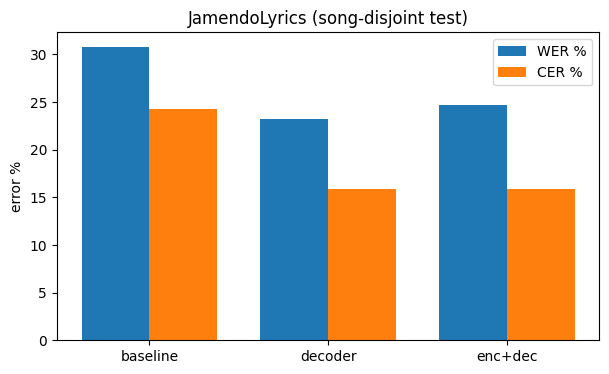

In [17]:
# results and chart
import matplotlib.pyplot as plt
def rel(r): return 100*(baseline["wer"]-r["wer"])/baseline["wer"]
print(f"{'approach':<22}{'WER%':>8}{'CER%':>8}{'relWER':>9}")
print(f"{'baseline':<22}{baseline['wer']:>8}{baseline['cer']:>8}{'-':>9}")
for nm, r in [("decoder_only", dec), ("encoder_decoder", enc)]:
    print(f"{nm:<22}{r['wer']:>8}{r['cer']:>8}{rel(r):>8.1f}%")
print("target >15%:", "met" if max(rel(dec), rel(enc)) >= 15 else "not met")

labels = ["baseline", "decoder", "enc+dec"]
wer = [baseline["wer"], dec["wer"], enc["wer"]]; cer = [baseline["cer"], dec["cer"], enc["cer"]]
x = range(3); w = 0.38; fig, ax = plt.subplots(figsize=(7, 4))
ax.bar([i-w/2 for i in x], wer, w, label="WER %"); ax.bar([i+w/2 for i in x], cer, w, label="CER %")
ax.set_xticks(list(x)); ax.set_xticklabels(labels); ax.set_ylabel("error %"); ax.legend()
ax.set_title("JamendoLyrics (song-disjoint test)"); plt.show()

In [18]:
# gradio demo
import gradio as gr
from peft import PeftModel
best = "encoder_decoder" if enc["wer"] <= dec["wer"] else "decoder_only"
demo_model = WhisperForConditionalGeneration.from_pretrained(MODEL_NAME, torch_dtype=torch.float16).to(DEVICE)
demo_model = PeftModel.from_pretrained(demo_model, str(CKPT/best/"best_adapter")).eval()
demo_model.generation_config.language = "english"; demo_model.generation_config.task = "transcribe"
demo_model.generation_config.forced_decoder_ids = None

def resample(y, sr, t=16000):
    if sr == t: return y
    n = int(round(len(y)*t/sr))
    return np.interp(np.linspace(0,1,n,endpoint=False), np.linspace(0,1,len(y),endpoint=False), y).astype(np.float32)

def transcribe(audio):
    if audio is None: return "No audio."
    sr, data = audio; data = np.asarray(data)
    data = data.astype(np.float32)/np.iinfo(data.dtype).max if data.dtype.kind in "iu" else data.astype(np.float32)
    if data.ndim > 1: data = data.mean(axis=1)
    data = resample(data, sr)
    feats = processor(data, sampling_rate=16000, return_tensors="pt").input_features.to(DEVICE, torch.float16)
    with torch.no_grad():
        ids = demo_model.generate(input_features=feats, language="english", task="transcribe", max_new_tokens=225)
    return processor.batch_decode(ids, skip_special_tokens=True)[0].strip() or "[no speech]"

gr.Interface(transcribe, gr.Audio(sources=["upload","microphone"], type="numpy"),
             gr.Textbox(label="Transcription"), title="AutoLyrics").launch(share=True)

Loading weights:   0%|          | 0/479 [00:00<?, ?it/s]

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://b8fb6b2eac6f75bbcb.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
